In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
# import geopy.distances
from tqdm import tqdm
from sklearn.decomposition import PCA
from scipy.stats import zscore
import seaborn as sns
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl
import overlap_utils as ou

In [6]:
folder = '/Users/tplas/Downloads/'

fname = 'cropharvest_cleaned_Kenya.csv'

fpath = os.path.join(folder, fname)

df_crop = pd.read_csv(fpath)

from collections import Counter
df_crop.label_name.value_counts(), len(df_crop)

(label_name
 millet            200
 Other             105
 red clover         58
 tournesol          23
 white sorghum      16
 eggplant           10
 menthe              7
 cherries            3
 winter wheat        2
 colza dhiver       2
 avoine dhiver      2
 broadleaf           2
 winter rye          1
 ryegrass            1
 radis               1
 Name: count, dtype: int64,
 2855)

In [138]:
folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/downstream_tasks/'

fname = 'biomass_cleaned_centre.csv'

fpath = os.path.join(folder, fname)

df_biomass = pd.read_csv(fpath)
df_biomass
# len(df_biomass), sum(df_biomass.biomass_center != -9999.0)
# gdf_biomass = gpd.GeoDataFrame(df_biomass, geometry=gpd.points_from_xy(df_biomass.lon, df_biomass.lat))
# gdf_biomass_centre = gdf_biomass[gdf_biomass.biomass_center != -9999.0]
# len(gdf_biomass_centre), len(df_biomass)

,index,lon,lat,biomass_mean,biomass_closest,biomass_center
0,4,140.664249,41.991077,171.093713,147.429977,147.429977
1,7,-106.155144,25.085021,183.963731,141.985489,141.985489
2,11,26.867304,9.128486,10.689733,5.694790,5.694790
3,15,134.776750,51.577753,37.108577,76.696602,76.696602
4,19,8.087109,51.171656,134.051117,51.654457,51.654457
...,...,...,...,...,...,...
4580,18366,-105.833088,23.656093,284.270788,445.650177,445.650177
4581,18367,95.335814,15.847863,1.836089,2.602650,2.602650
4582,18372,18.225458,40.019798,94.787301,10.238476,10.238476
4583,18373,-106.792066,28.218339,20.853441,9.994730,9.994730


In [149]:
mapping_index = {ii: int(df_biomass['index'].values[ii]) for ii in range(len(df_biomass))}
# mapping_index
folder_load = '/Users/tplas/Downloads/tmp_biomass/'
folder_save = '/Users/tplas/data/dw_sampled_locations/data_spherical/alphaearth/'

assert os.path.exists(folder_load), f'{folder_load} does not exist.'
assert os.path.exists(folder_save), f'{folder_save} does not exist.'

for fname in tqdm(os.listdir(folder_load)):
    assert fname.startswith('biomass_'), f'{fname} does not start with "biomass_".'
    assert fname.endswith('.tif'), f'{fname} does not end with ".tif".'

    tmp_ind = int(fname.split('_')[1])
    assert tmp_ind in mapping_index, f'{tmp_ind} not in mapping_index.'
    new_ind = mapping_index[tmp_ind]

    new_fname = fname.replace('biomass_' + str(tmp_ind), 'biomass_' + str(new_ind))
    # print(f'Copying {fname} to {new_fname}...')
    ## move file from folder_load to folder_save with new name
    os.rename(os.path.join(folder_load, fname), os.path.join(folder_save, new_fname))

100%|██████████| 4581/4581 [00:00<00:00, 13267.07it/s]


<Axes: >

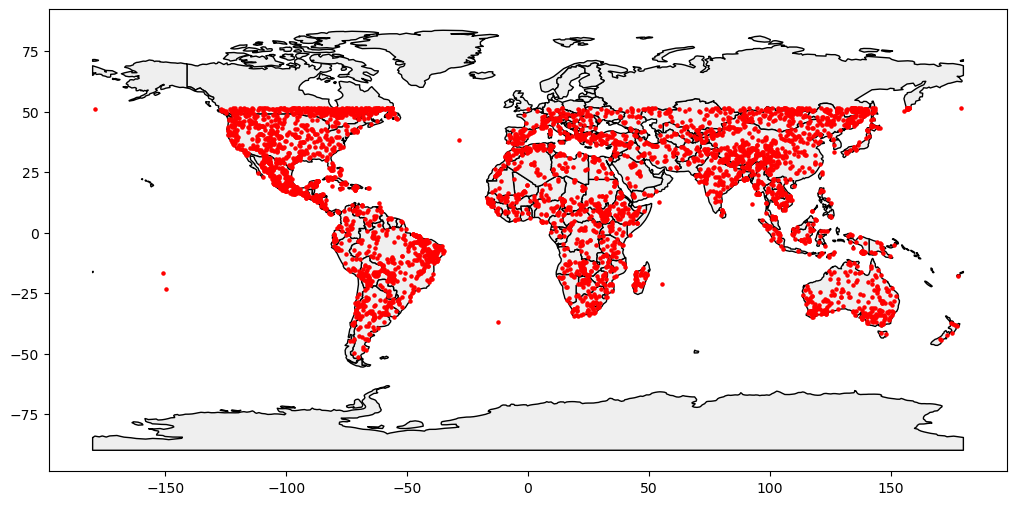

In [18]:
countries = gpd.read_file('/Users/tplas/data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_biomass_centre.plot(ax=ax, color='red', markersize=5)

In [97]:
df_biomass[df_biomass.biomass_center != -9999.0]#.to_csv(os.path.join(folder, 'biomass_cleaned_centre.csv'), index=False)

,index,lon,lat,biomass_mean,biomass_closest,biomass_center
4,4,140.664249,41.991077,171.093713,147.429977,147.429977
7,7,-106.155144,25.085021,183.963731,141.985489,141.985489
11,11,26.867304,9.128486,10.689733,5.694790,5.694790
15,15,134.776750,51.577753,37.108577,76.696602,76.696602
19,19,8.087109,51.171656,134.051117,51.654457,51.654457
...,...,...,...,...,...,...
18366,18366,-105.833088,23.656093,284.270788,445.650177,445.650177
18367,18367,95.335814,15.847863,1.836089,2.602650,2.602650
18372,18372,18.225458,40.019798,94.787301,10.238476,10.238476
18373,18373,-106.792066,28.218339,20.853441,9.994730,9.994730


Total samples: 70213
Total non-None labels: 50841
Total None labels: 19372
Labels with more than 200 samples: 18


/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_49665/2014942393.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gdf_crop_sel = gdf_crop_sel.groupby('label_name').apply(lambda x: x.sample(n_sample, random_state=0)).reset_index(drop=True)


<Axes: >

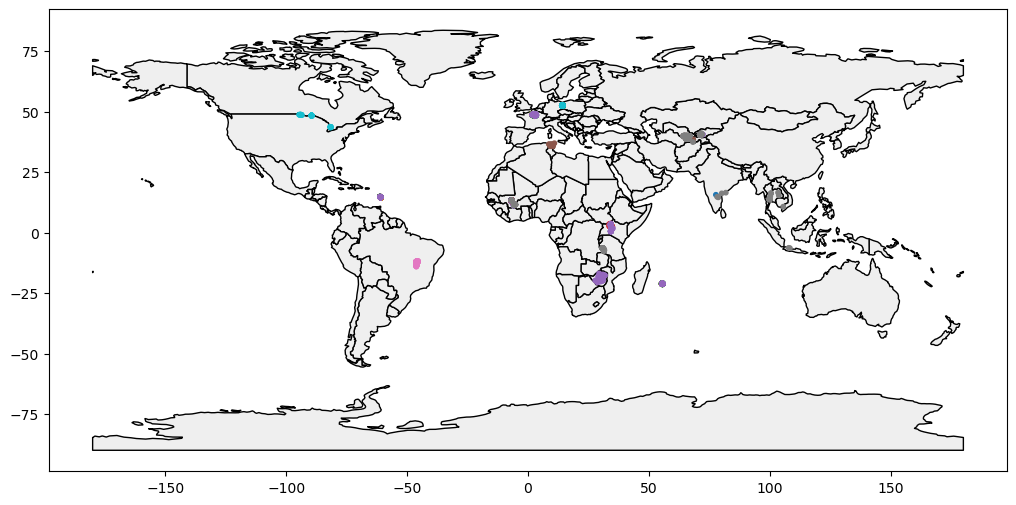

In [243]:
folder = '/Users/tplas/Downloads/CropHarvest'

fname = 'cropharvest_cleaned_global.csv'

fpath = os.path.join(folder, fname)

df_crop = pd.read_csv(fpath)
gdf_crop = gpd.GeoDataFrame(df_crop, geometry=gpd.points_from_xy(df_crop.lon, df_crop.lat))
from collections import Counter
print(f'Total samples: {len(df_crop)}')
print(f'Total non-None labels: {sum(df_crop.label_name.notnull())}')
print(f'Total None labels: {sum(df_crop.label_name.isnull())}')
dict_label_counts = {k: int(v) for k, v in df_crop.label_name.value_counts().items()}
del dict_label_counts['Other']

threshold = 200
dict_label_counts_sel = {k: v for k, v in dict_label_counts.items() if v >= threshold}
print(f'Labels with more than 200 samples: {len(dict_label_counts_sel)}')
crop_names_sel = list(dict_label_counts_sel.keys())
gdf_crop_sel = gdf_crop[gdf_crop.label_name.isin(crop_names_sel)]
n_sample = threshold

## sample n_sample points from each crop class
gdf_crop_sel = gdf_crop_sel.groupby('label_name').apply(lambda x: x.sample(n_sample, random_state=0)).reset_index(drop=True)

# ind += 1 
# n_sample = 200
# gdf_crop_sel = gdf_crop[gdf_crop.label_name == crop_names_sel[ind]]
# if len(gdf_crop_sel) > n_sample:
#     gdf_crop_sel = gdf_crop_sel.sample(n_sample, random_state=0)

fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_crop_sel.plot(ax=ax, column='label_name', markersize=10, legend=False)
# plt.title(f'Crop: {crop_names_sel[ind]}')

In [251]:
# gdf_crop_sel.to_csv(os.path.join(folder, f'cropharvest_cleaned_global_threshold-{threshold}-sample.csv'), index=False)

tmp = os.listdir('/Users/tplas/data/dw_sampled_locations/data_spherical/alphaearth/')
len([x for x in tmp if x[0] in '1234567890' and x.endswith('.tif')])

18969

Text(0.5, 1.0, 'Multiclass data (29748/70213 samples)')

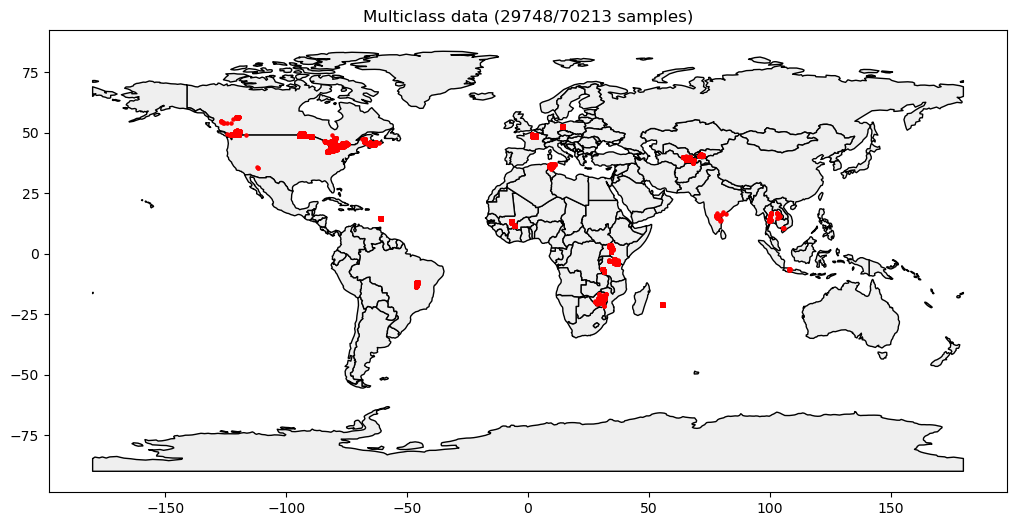

In [90]:
countries = gpd.read_file('/Users/tplas/data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

fig, ax = plt.subplots(figsize=(20,6))
countries.plot(ax=ax, color="#EFEFEF", edgecolor='black')
gdf_sel = gdf_crop[gdf_crop.label_name.notnull()]
gdf_sel = gdf_sel[gdf_sel.label_name != 'Other']
# gdf_sel = gdf_crop[np.logical_or(gdf_crop.label_name == 'Other', gdf_crop.label_name.isnull())]
gdf_sel.plot(ax=ax, color='red', markersize=5)
plt.title(f'Multiclass data ({len(gdf_sel)}/{len(gdf_crop)} samples)')

Text(0, 0.5, 'Number of samples')

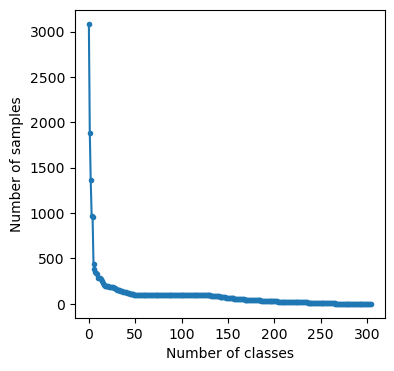

In [80]:
class_counts = dict(df_crop.label_name.value_counts())
del class_counts['Other']

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.plot(np.sort(list(class_counts.values()))[::-1], '.-')
ax.set_xlabel('Number of classes')
ax.set_ylabel('Number of samples')

In [75]:
min_datapoints = 200 

n_datapoints = np.array([int(x) for x in dict(df_crop.label_name.value_counts()).values()])[1:] 
inds_enough = np.where(n_datapoints >= min_datapoints)[0]

dict_n_datapoints_sampled = {k + 1: int((k + 1) * min_datapoints) for k, min_datapoints in enumerate(n_datapoints)}
print(f'Number of classes with at least {min_datapoints} datapoints: {len(inds_enough)}. Total number of datapoints in these classes: {sum(n_datapoints[inds_enough])}. Or {len(inds_enough) * min_datapoints} datapoints if we downsample to {min_datapoints} per class.')


Number of classes with at least 200 datapoints: 18. Total number of datapoints in these classes: 12099. Or 3600 datapoints if we downsample to 200 per class.


In [70]:
n_datapoints

array([3086, 1883, 1359,  964,  961,  437,  381,  354,  341,  329,  284,
        282,  279,  274,  251,  231,  203,  200,  199,  198,  197,  194,
        189,  187,  186,  186,  185,  179,  177,  167,  157,  153,  150,
        148,  146,  145,  139,  134,  134,  133,  126,  122,  120,  118,
        113,  108,  107,  107,  107,  102,  102,  101,  101,  101,  101,
        100,  100,  100,  100,  100,  100,  100,  100,  100,  100,  100,
        100,  100,  100,  100,  100,  100,  100,  100,  100,  100,  100,
        100,  100,  100,  100,  100,  100,  100,  100,  100,  100,  100,
        100,  100,  100,  100,  100,  100,  100,  100,  100,  100,  100,
        100,  100,  100,  100,  100,  100,  100,  100,  100,  100,  100,
        100,  100,  100,  100,  100,  100,  100,  100,  100,  100,  100,
         99,   99,   98,   97,   97,   97,   97,   96,   95,   94,   93,
         91,   87,   86,   85,   84,   84,   83,   83,   81,   79,   79,
         77,   75,   73,   73,   71,   69,   69,   

Max number of samples: 12416 for 128 classes.


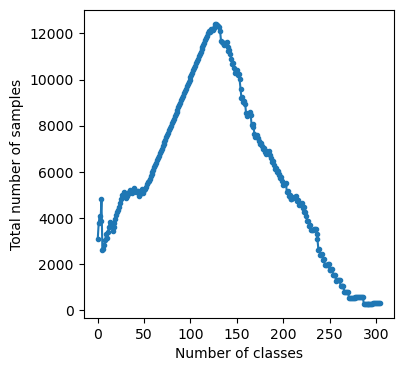

In [158]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111)
ax.plot(list(dict_n_datapoints_sampled.values()), '.-')
ax.set_xlabel('Number of classes')
ax.set_ylabel('Total number of samples')
# ax.set_xlim(0, 50)

argmax = np.argmax(list(dict_n_datapoints_sampled.values()))
print(f'Max number of samples: {dict_n_datapoints_sampled[argmax + 1]} for {argmax + 1} classes.')